In [ ]:
#pip install yfinance

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [28]:
# Define the list of tickers and download historical adjusted close prices
tickers = ['AAPL', 'META','GOOGL','COST','WMT','AMZN','TSLA']
data = yf.download(tickers, start='2023-01-01', end='2025-01-01')['Close']

[*********************100%***********************]  7 of 7 completed


In [29]:
data.head()

Ticker,AAPL,AMZN,COST,GOOGL,META,TSLA,WMT
Date,,,,,,,
2023-01-03,123.632530,85.820000,436.833832,88.798103,124.265312,108.099998,46.589115
2023-01-04,124.907700,85.139999,439.994812,87.761856,126.885323,113.639999,46.641018
2023-01-05,123.583107,83.120003,433.855896,85.888649,126.456940,110.339996,46.482052
2023-01-06,128.130234,86.080002,465.350189,87.024521,129.525223,113.059998,47.620819
2023-01-09,128.654144,87.360001,461.379669,87.702065,128.977325,119.769997,47.027103


In [30]:
# Calculate daily returns and drop any missing values
returns = data.pct_change().dropna()

In [31]:
returns.head()

Ticker,AAPL,AMZN,COST,GOOGL,META,TSLA,WMT
Date,,,,,,,
2023-01-04,0.010314,-0.007924,0.007236,-0.011670,0.021084,0.051249,0.001114
2023-01-05,-0.010605,-0.023726,-0.013952,-0.021344,-0.003376,-0.029039,-0.003408
2023-01-06,0.036794,0.035611,0.072592,0.013225,0.024263,0.024651,0.024499
2023-01-09,0.004089,0.014870,-0.008532,0.007786,-0.004230,0.059349,-0.012468
2023-01-10,0.004456,0.028732,0.005535,0.004544,0.027188,-0.007681,-0.000621


In [32]:
# scale features before PCA
scaler = StandardScaler()
# fit scaler by returns
scaler.fit(returns)
# Apply transform scale returns
returns_sc = scaler.transform(returns)

In [33]:
# Perform PCA on the returns, treating each stock as a feature
pca = PCA(n_components=2)  # We'll reduce the dimensionality to 2 components
principal_components = pca.fit_transform(returns_sc)

In [34]:
# Create a DataFrame for the principal components with dates as index
pc_df = pd.DataFrame(data=principal_components, index=returns.index, columns=['PC1', 'PC2'])
pc_df.head()

,PC1,PC2
Date,,
2023-01-04,0.620152,-0.278256
2023-01-05,-2.468840,0.240984
2023-01-06,5.292410,-3.566161
2023-01-09,0.296646,1.504882
2023-01-10,1.182629,0.511067


In [35]:
# Display the proportion of variance explained by each component
print("Explained Variance Ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio:.2%}")

Explained Variance Ratio:
PC1: 43.45%
PC2: 16.78%


In [36]:
# Display the loadings (coefficients) for each variable
loadings = pca.components_.T  # Each column corresponds to a PC
# Create a DataFrame for the loadings with tickers as index
loadings_df = pd.DataFrame(data=loadings, index=tickers, columns=['PC1', 'PC2'])
print(loadings_df)

            PC1       PC2
AAPL   0.389006  0.132264
META   0.454731  0.145597
GOOGL  0.369364 -0.485230
COST   0.422465  0.301225
WMT    0.419817  0.245022
AMZN   0.326880 -0.029994
TSLA   0.209501 -0.757751


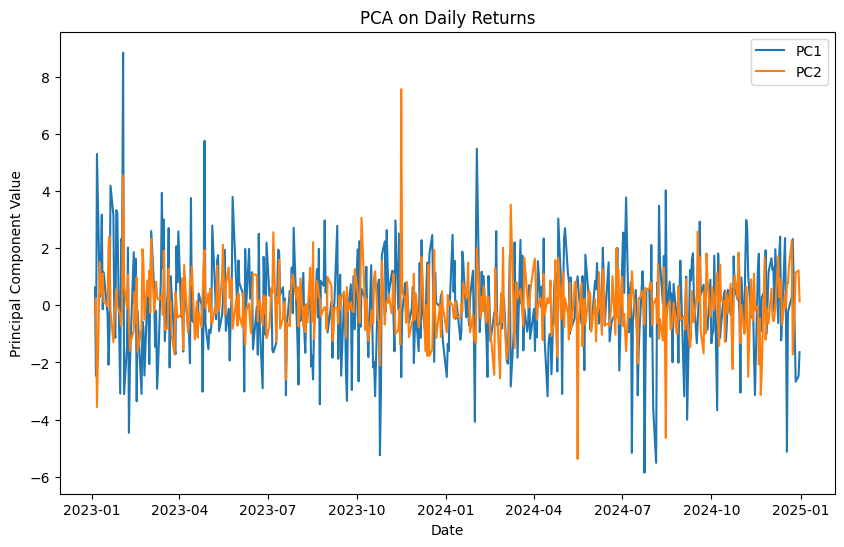

In [37]:
# Plot the principal components over time
plt.figure(figsize=(10, 6))
plt.plot(pc_df.index, pc_df['PC1'], label='PC1')
plt.plot(pc_df.index, pc_df['PC2'], label='PC2')
plt.xlabel('Date')
plt.ylabel('Principal Component Value')
plt.title('PCA on Daily Returns')
plt.legend()
plt.show()


In [38]:
# Define a function to create a biplot
def biplot(scores, coeff, labels=None):
    xs = scores[:, 0]
    ys = scores[:, 1]
    
    # Scale the scores to improve the biplot appearance
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    
    plt.figure(figsize=(10, 7))
    plt.scatter(xs * scalex, ys * scaley, c='grey', alpha=0.5)
    
    # Plot arrows for each variable (loading)
    for i in range(coeff.shape[0]):
        plt.arrow(0, 0, coeff[i, 0], coeff[i, 1],
                  color='r', width=0.002, head_width=0.02)
        if labels is None:
            plt.text(coeff[i, 0] * 1.1, coeff[i, 1] * 1.1,
                     "Var"+str(i+1), color='g', fontsize=10)
        else:
            plt.text(coeff[i, 0] * 1.1, coeff[i, 1] * 1.1,
                     labels[i], color='b', fontsize=10)
    
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot of Financial Returns PCA")
    plt.grid()
    plt.show()

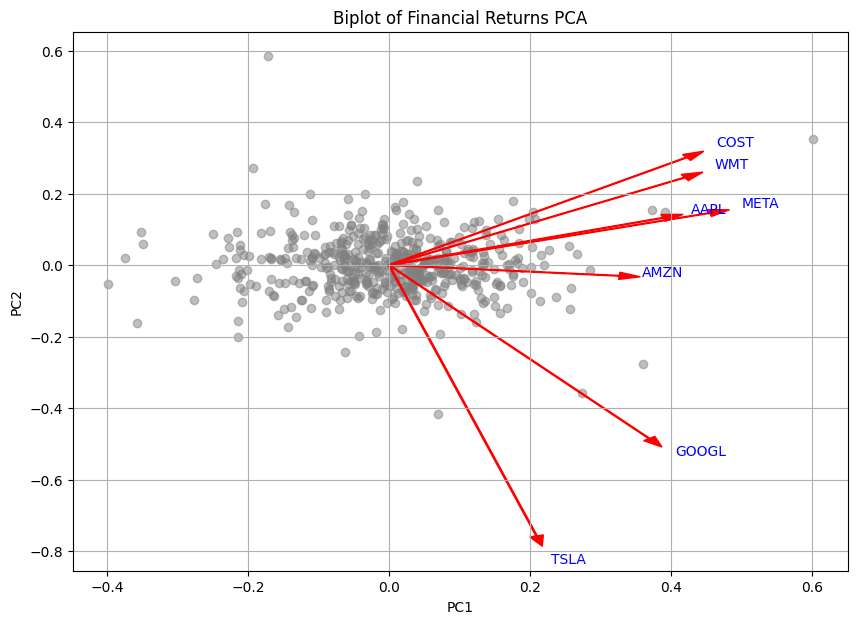

In [39]:
# Create a biplot with the PCA scores and variable loadings
pca_result = pca.fit_transform(returns_sc)
biplot(pca_result, pca.components_.T, labels=tickers)